In [ ]:
!pip install --upgrade pip
!pip install SimpleITK
!pip install --no-cache-dir git+https://github.com/Radiomics/pyradiomics.git
!pip install albumentations timm scikit-learn matplotlib torch torchvision tqdm opencv-python

  Cloning https://github.com/Radiomics/pyradiomics.git to /tmp/pip-req-build-x0202eh6
  Running command git clone --filter=blob:none --quiet https://github.com/Radiomics/pyradiomics.git /tmp/pip-req-build-x0202eh6
  Resolved https://github.com/Radiomics/pyradiomics.git to commit 8ed579383b44806651c463d5e691f3b2b57522ab
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Installing backend dependencies ... done
  Preparing metadata (pyproject.toml) ... done
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 753.1/753.1 kB 37.1 MB/s  0:00:00
  Created wheel for pyradiomics: filename=pyradiomics-3.1.1.dev111+g8ed579383-cp312-cp312-linux_x86_64.whl size=121811 sha256=38fa1c14e857a4fbff611fba890a98b3f2c64642d4eabb5ae790e7c25d382184
  Stored in directory: /tmp/pip-ephem-wheel-cache-36tzxj0f/wheels/33/e9/c0/7de3e16cb600bae494d4a94dcd6c30a0443f06fb7359e87aa3
  DEPRECATION: Building 'docopt' using the legacy setup.py bdist_

In [ ]:
import os, cv2, numpy as np, torch, random
from torch.utils.data import Dataset, DataLoader
from torchvision import models
import torch.nn as nn
import torch.optim as optim
from tqdm import tqdm
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.model_selection import train_test_split
import albumentations as A
from albumentations.pytorch import ToTensorV2


In [ ]:

import SimpleITK as sitk
from radiomics import featureextractor

In [ ]:
!unzip -q "/content/archive.zip" -d /content/dataset

In [ ]:
dataset_path = "/content/dataset/brain_tumor_dataset"  # adjust if needed
rad_cache_dir = "/content/dataset/radiomics_cache"
os.makedirs(rad_cache_dir, exist_ok=True)
RAD_DIM = 50    # same as before (we'll truncate/pad)
SEED = 42
torch.manual_seed(SEED); np.random.seed(SEED); random.seed(SEED)


In [ ]:
extractor = featureextractor.RadiomicsFeatureExtractor()
extractor.enableAllFeatures()
extractor.enableAllImageTypes()


INFO:radiomics.featureextractor:No valid config parameter, using defaults: {'minimumROIDimensions': 2, 'minimumROISize': None, 'normalize': False, 'normalizeScale': 1, 'removeOutliers': None, 'resampledPixelSpacing': None, 'interpolator': 'sitkBSpline', 'preCrop': False, 'padDistance': 5, 'distances': [1], 'force2D': False, 'force2Ddimension': 0, 'resegmentRange': None, 'label': 1, 'additionalInfo': True}
INFO:radiomics.featureextractor:Enabled image types: {'Original': {}}
INFO:radiomics.featureextractor:Enabled features: {'firstorder': [], 'glcm': [], 'gldm': [], 'glrlm': [], 'glszm': [], 'ngtdm': [], 'shape': []}


In [ ]:
def extract_radiomics_pyrad_raw(image_path, rad_dim=RAD_DIM):
    """
    Extract and return a numpy array of length rad_dim.
    If extraction fails returns zeros.
    """
    try:
        img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
        img_resized = cv2.resize(img, (128,128))
        itk_img = sitk.GetImageFromArray(img_resized)
        mask = np.ones_like(img_resized, dtype=np.uint8)
        itk_mask = sitk.GetImageFromArray(mask)
        features = extractor.execute(itk_img, itk_mask)
        values = [v for k,v in features.items() if isinstance(v,(int,float))]
        # keep deterministic selection: first N numeric values
        values = values[:rad_dim] + [0]*(rad_dim - len(values))
        return np.array(values, dtype=np.float32)
    except Exception as e:
        # fallback
        return np.zeros(rad_dim, dtype=np.float32)

def cache_radiomics_for_dataset(root_dir, cache_dir, rad_dim=RAD_DIM):
    """
    Walk dataset structure: expects subfolders 'no' and 'yes'.
    Saves one .npy per image in cache_dir with same filename + .npy
    """
    for label_folder in ["no","yes"]:
        folder = os.path.join(root_dir, label_folder)
        if not os.path.exists(folder): continue
        for fname in os.listdir(folder):
            if not fname.lower().endswith((".jpg",".png")): continue
            img_path = os.path.join(folder, fname)
            cache_path = os.path.join(cache_dir, f"{label_folder}__{fname}.npy")
            if os.path.exists(cache_path):
                continue
            rad = extract_radiomics_pyrad_raw(img_path, rad_dim=rad_dim)
            np.save(cache_path, rad)

# Precompute and cache radiomics (first run will take time)
cache_radiomics_for_dataset(dataset_path, rad_cache_dir, rad_dim=RAD_DIM)

Streaming output truncated to the last 5000 lines.
INFO:radiomics.featureextractor:Computing firstorder
INFO:radiomics.featureextractor:Computing glcm
GLCM is symmetrical, therefore Sum Average = 2 * Joint Average, only 1 needs to be calculated
INFO:radiomics.featureextractor:Computing gldm
INFO:radiomics.featureextractor:Computing glrlm
INFO:radiomics.featureextractor:Computing glszm
INFO:radiomics.featureextractor:Computing ngtdm
INFO:radiomics.featureextractor:Calculating features for exponential image
INFO:radiomics.featureextractor:Computing firstorder
INFO:radiomics.featureextractor:Computing glcm
GLCM is symmetrical, therefore Sum Average = 2 * Joint Average, only 1 needs to be calculated
INFO:radiomics.featureextractor:Computing gldm
INFO:radiomics.featureextractor:Computing glrlm
INFO:radiomics.featureextractor:Computing glszm
INFO:radiomics.featureextractor:Computing ngtdm
INFO:radiomics.featureextractor:Calculating features for gradient image
INFO:radiomics.featureextractor:

In [ ]:
class BrainMRIDatasetCached(Dataset):
    def __init__(self, root_dir, cache_dir, transform=None, scaler=None, use_cache=True, modality_dropout_p=0.0):
        self.samples = []
        self.labels = []
        self.transform = transform
        self.scaler = scaler  # sklearn StandardScaler fitted on train radiomics
        self.cache_dir = cache_dir
        self.modality_dropout_p = modality_dropout_p
        for label, folder in enumerate(["no", "yes"]):
            folder_path = os.path.join(root_dir, folder)
            if not os.path.exists(folder_path): continue
            for f in os.listdir(folder_path):
                if f.lower().endswith((".jpg",".png")):
                    img_path = os.path.join(folder_path, f)
                    cache_name = os.path.join(cache_dir, f"{folder}__{f}.npy")
                    self.samples.append((img_path, cache_name))
                    self.labels.append(label)
    def __len__(self):
        return len(self.samples)
    def __getitem__(self, idx):
        img_path, cache_path = self.samples[idx]
        label = self.labels[idx]
        image = cv2.imread(img_path)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        if self.transform:
            image = self.transform(image=image)["image"]
        # load cached rad
        rad = np.load(cache_path)
        # scale if scaler present
        if self.scaler is not None:
            rad = self.scaler.transform(rad.reshape(1,-1)).squeeze()
        rad = torch.tensor(rad, dtype=torch.float32)

        # Apply modality dropout
        if self.modality_dropout_p > 0 and self.transform.transforms[-1].__class__.__name__ == 'ToTensorV2':
            if random.random() < self.modality_dropout_p:
                # Randomly drop either image or radiomics
                if random.random() < 0.5:
                    image = torch.zeros_like(image) # Drop image
                else:
                    rad = torch.zeros_like(rad)     # Drop radiomics

        return image, rad, torch.tensor(label, dtype=torch.long)

In [ ]:
train_transform = A.Compose([
    A.Resize(224, 224),
    A.Rotate(limit=15, p=0.7),
    A.Affine(translate_percent=0.05, scale=(0.9, 1.1), rotate=0, shear=0, p=0.5),
    A.ElasticTransform(alpha=1, sigma=50, p=0.3),
    A.RandomBrightnessContrast(brightness_limit=0.2, contrast_limit=0.2, p=0.5),
    A.GaussNoise(p=0.4),
    A.OneOf([
        A.MotionBlur(blur_limit=3, p=1.0),
        A.MedianBlur(blur_limit=3, p=1.0),
        A.Blur(blur_limit=3, p=1.0),
    ], p=0.3),
    A.HueSaturationValue(hue_shift_limit=10, sat_shift_limit=20, val_shift_limit=10, p=0.3),
    A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
    ToTensorV2()
])
val_transform = A.Compose([
    A.Resize(224, 224),
    A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
    ToTensorV2()
])

In [ ]:
all_rad_paths, all_labels, all_img_paths = [], [], []
for label, folder in enumerate(["no","yes"]):
    folder_path = os.path.join(dataset_path, folder)
    if not os.path.exists(folder_path): continue
    for f in os.listdir(folder_path):
        if f.lower().endswith((".jpg",".png")):
            cache_name = os.path.join(rad_cache_dir, f"{folder}__{f}.npy")
            if os.path.exists(cache_name):
                all_rad_paths.append(cache_name)
                all_img_paths.append(os.path.join(folder_path, f))
                all_labels.append(label)

# stratified split
train_idx, test_idx = train_test_split(np.arange(len(all_rad_paths)), test_size=0.2, random_state=SEED, stratify=all_labels)
# fit scaler on train radiomics
train_rads = [np.load(all_rad_paths[i]) for i in train_idx]
train_rads = np.vstack(train_rads)
scaler = StandardScaler().fit(train_rads)

# Create dataset objects using the scaler
full_dataset = BrainMRIDatasetCached(dataset_path, rad_cache_dir, transform=train_transform, scaler=None)
# We'll create indices for splits and then create Subset-like access
from torch.utils.data import Subset
train_indices = train_idx.tolist()
test_indices = test_idx.tolist()

# Important: create two dataset objects that share same underlying list but different transforms & scaler
train_dataset = BrainMRIDatasetCached(dataset_path, rad_cache_dir, transform=train_transform, scaler=scaler)
test_dataset = BrainMRIDatasetCached(dataset_path, rad_cache_dir, transform=val_transform, scaler=scaler)

# But only keep relevant indices:
train_dataset = Subset(train_dataset, train_indices)
test_dataset  = Subset(test_dataset, test_indices)

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True, num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_dataset, batch_size=16, shuffle=False, num_workers=2, pin_memory=True)


In [ ]:
class FusionModelGated(nn.Module):
    def __init__(self, rad_dim=RAD_DIM, num_classes=2, dropout_p=0.4):
        super().__init__()
        self.cnn = models.resnet18(pretrained=True)
        self.cnn.fc = nn.Identity()  # remove final classification
        # radiomics embedding
        self.fc_rad = nn.Sequential(
            nn.Linear(rad_dim, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, 128),
            nn.BatchNorm1d(128),
            nn.ReLU()
        )
        # gating: learns alpha in (0,1) per sample
        # compute gate from concatenated features (512 + 128) -> scalar via sigmoid
        self.gate = nn.Sequential(
            nn.Linear(512 + 128, 128),
            nn.ReLU(),
            nn.Linear(128, 1),
            nn.Sigmoid()
        )
        # fusion MLP (deeper)
        self.fc_fusion = nn.Sequential(
            nn.Linear(512 + 128, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(dropout_p),
            nn.Linear(256, num_classes)
        )
        # modality dropout prob (set externally during train loop)
        self.modality_dropout_p = 0.0

    def forward(self, img, rad, is_training=False):
        # img: (B,3,224,224)
        cnn_feat = self.cnn(img)   # (B,512)
        rad_feat = self.fc_rad(rad)  # (B,128)
        # modality dropout: occasionally zero-out rad (only during training)
        if is_training and self.modality_dropout_p > 0.0:
            mask = (torch.rand(rad_feat.size(0), device=rad_feat.device) > self.modality_dropout_p).float().unsqueeze(1)
            rad_feat = rad_feat * mask
        # gating
        concat = torch.cat([cnn_feat, rad_feat], dim=1)
        alpha = self.gate(concat)  # (B,1)
        fused = alpha * cnn_feat + (1.0 - alpha) * torch.cat([rad_feat, torch.zeros_like(cnn_feat[:, :384])], dim=1)[:,:512]
        # The above ensures shapes match: we bias the rad into same dim; simpler approach is concatenation below
        # But for stability use concatenation for fusion MLP:
        fused_cat = torch.cat([cnn_feat, rad_feat], dim=1)
        out = self.fc_fusion(fused_cat)
        return out, alpha.squeeze(1)

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = FusionModelGated(rad_dim=RAD_DIM, num_classes=2, dropout_p=0.4).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-4, weight_decay=1e-4)  # add weight decay
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=10, eta_min=1e-6)

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 108MB/s]


In [ ]:
# ---------- Utility: Plot training/validation curves ----------
def plot_training_curves(train_acc, val_acc, train_loss, val_loss):
    epochs = range(1, len(train_acc) + 1)

    plt.figure(figsize=(12,5))

    # Accuracy plot
    plt.subplot(1,2,1)
    plt.plot(epochs, train_acc, '-o', label='Train Accuracy')
    plt.plot(epochs, val_acc, '-o', label='Validation Accuracy')
    plt.title('Accuracy Curve')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy (%)')
    plt.legend()
    plt.grid(True)

    # Loss plot
    plt.subplot(1,2,2)
    plt.plot(epochs, train_loss, '-o', label='Train Loss')
    plt.plot(epochs, val_loss, '-o', label='Validation Loss')
    plt.title('Loss Curve')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True)

    plt.show()


In [ ]:
def train_model(model, train_loader, test_loader, epochs=30, patience=6, modality_dropout_p=0.25):
    best_val = 0.0
    bad = 0

    # Store metrics
    train_acc_list, val_acc_list = [], []
    train_loss_list, val_loss_list = [], []

    model.modality_dropout_p = modality_dropout_p

    for epoch in range(epochs):
        # ---- Train ----
        model.train()
        running_loss = 0.0
        correct = total = 0
        for imgs, rads, labels in tqdm(train_loader, desc=f"Train Epoch {epoch+1}"):
            imgs = imgs.to(device)
            rads = rads.to(device)
            labels = labels.to(device)

            optimizer.zero_grad()
            outputs, alpha = model(imgs, rads, is_training=True)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * imgs.size(0)
            preds = outputs.argmax(dim=1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

        train_loss = running_loss / len(train_loader.dataset)
        train_acc = 100.0 * correct / total
        train_loss_list.append(train_loss)
        train_acc_list.append(train_acc)

        scheduler.step()

        # ---- Validate ----
        model.eval()
        val_running_loss = 0.0
        correct = total = 0
        with torch.no_grad():
            for imgs, rads, labels in test_loader:
                imgs = imgs.to(device)
                rads = rads.to(device)
                labels = labels.to(device)

                outputs, alpha = model(imgs, rads, is_training=False)
                loss = criterion(outputs, labels)
                val_running_loss += loss.item() * imgs.size(0)

                preds = outputs.argmax(dim=1)
                correct += (preds == labels).sum().item()
                total += labels.size(0)

        val_loss = val_running_loss / len(test_loader.dataset)
        val_acc = 100.0 * correct / total
        val_loss_list.append(val_loss)
        val_acc_list.append(val_acc)

        print(f"Epoch {epoch+1}/{epochs} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | "
              f"Train Acc: {train_acc:.2f}% | Val Acc: {val_acc:.2f}%")

        # ---- Early stopping ----
        if val_acc > best_val:
            best_val = val_acc
            bad = 0
            torch.save(model.state_dict(), "/content/best_fusion_model.pth")
        else:
            bad += 1

        if bad >= patience:
            print("Early stopping.")
            break

    # ---- Load best model ----
    model.load_state_dict(torch.load("/content/best_fusion_model.pth"))

    return train_acc_list, val_acc_list, train_loss_list, val_loss_list


Train Epoch 1: 100%|██████████| 13/13 [00:05<00:00,  2.42it/s]


Epoch 1/30 | Train Loss: 0.6976 | Val Loss: 0.5696 | Train Acc: 58.38% | Val Acc: 66.00%


Train Epoch 2: 100%|██████████| 13/13 [00:02<00:00,  4.64it/s]


Epoch 2/30 | Train Loss: 0.5088 | Val Loss: 0.4296 | Train Acc: 72.08% | Val Acc: 78.00%


Train Epoch 3: 100%|██████████| 13/13 [00:02<00:00,  4.45it/s]


...

Epoch 7/30 | Train Loss: 0.2575 | Val Loss: 0.2048 | Train Acc: 91.37% | Val Acc: 92.00%


Train Epoch 8: 100%|██████████| 13/13 [00:03<00:00,  4.27it/s]


Epoch 8/30 | Train Loss: 0.2364 | Val Loss: 0.1957 | Train Acc: 93.40% | Val Acc: 90.00%


Train Epoch 9: 100%|██████████| 13/13 [00:02<00:00,  4.34it/s]


Epoch 9/30 | Train Loss: 0.2569 | Val Loss: 0.1936 | Train Acc: 90.36% | Val Acc: 92.00%
Early stopping.


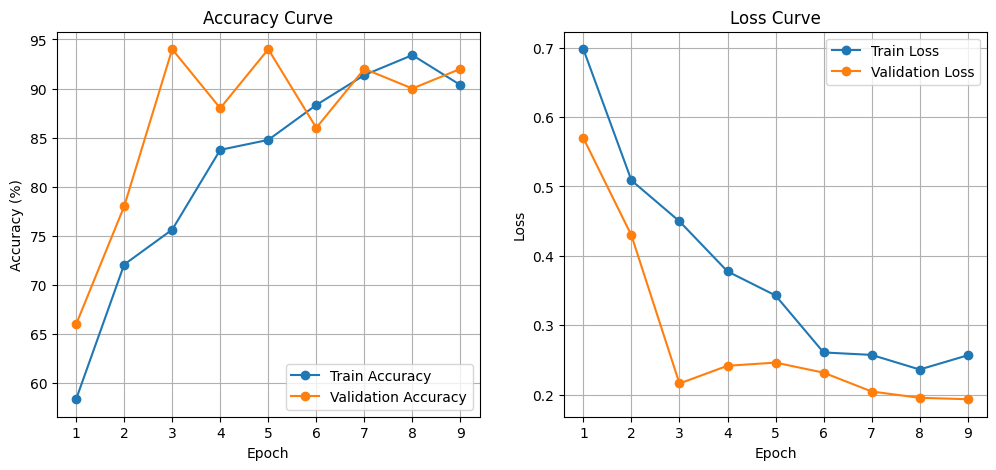

In [ ]:
train_acc, val_acc, train_loss, val_loss = train_model(
    model, train_loader, test_loader, epochs=30, patience=6, modality_dropout_p=0.25
)

plot_training_curves(train_acc, val_acc, train_loss, val_loss)


Final Test Accuracy: 0.94
Classification Report:
               precision    recall  f1-score   support

           0       1.00      0.84      0.91        19
           1       0.91      1.00      0.95        31

    accuracy                           0.94        50
   macro avg       0.96      0.92      0.93        50
weighted avg       0.95      0.94      0.94        50



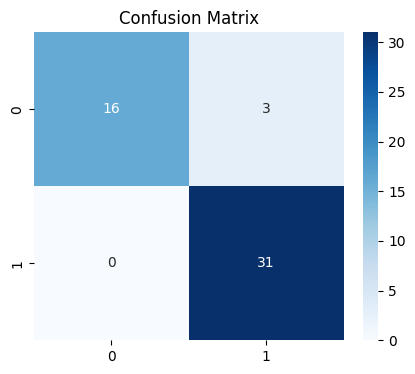

In [ ]:
model.eval()
all_preds = []
all_labels = []
all_alphas = []
with torch.no_grad():
    for imgs, rads, labels in test_loader:
        imgs = imgs.to(device); rads = rads.to(device)
        outputs, alpha = model(imgs, rads, is_training=False)
        preds = outputs.argmax(dim=1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())
        all_alphas.extend(alpha.cpu().numpy())

print("Final Test Accuracy:", accuracy_score(all_labels, all_preds))
print("Classification Report:\n", classification_report(all_labels, all_preds))

cm = confusion_matrix(all_labels, all_preds)
import seaborn as sns
plt.figure(figsize=(5,4)); sns.heatmap(cm, annot=True, fmt="d", cmap="Blues"); plt.title("Confusion Matrix"); plt.show()



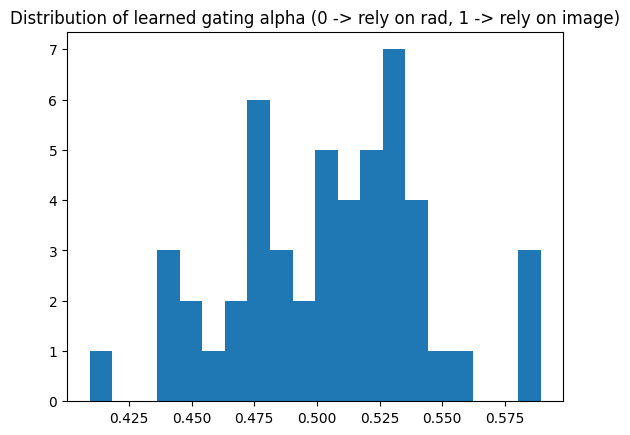

In [ ]:
# Inspect gating behavior (alpha distribution)
plt.hist(all_alphas, bins=20); plt.title("Distribution of learned gating alpha (0 -> rely on rad, 1 -> rely on image)"); plt.show()